In [5]:
import pandas as pd

df = pd.read_csv("Clean_Dataset.csv")
print(df.columns.tolist())
df.head()

['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [7]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [8]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [9]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [10]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [11]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [12]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [13]:
df['duration'].value_counts()

duration
2.17     4242
2.25     4036
2.75     2879
2.08     2755
2.83     2323
         ... 
37.17       1
38.75       1
38.50       1
36.25       1
41.50       1
Name: count, Length: 476, dtype: int64

In [14]:
df['duration'].min()

0.83

In [15]:
df['duration'].max()

49.83

In [16]:
df['duration'].median()

11.25

## PreProcessing

In [17]:
print(df.columns.tolist())
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)

['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [18]:
df.stops = pd.factorize(df.stops)[0]

In [19]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,Vistara,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585


In [20]:
df = df.join(pd.get_dummies(df.airline, prefix='airline')).drop('airline', axis=1)

df = df.join(pd.get_dummies(df.source_city, prefix='source')).drop('source_city', axis=1)

df = df.join(pd.get_dummies(df.destination_city, prefix='dest')).drop('destination_city', axis=1)

df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival')).drop('arrival_time', axis=1)

df = df.join(pd.get_dummies(df.departure_time, prefix='departure')).drop('departure_time', axis=1)

In [21]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


##  Training Regression model

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X , y = df.drop('price',axis=1), df.price


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2)

In [24]:
reg = RandomForestRegressor(n_jobs=-1)
reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [25]:
reg.score(X_test,y_test)

0.9854709188976117

In [26]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(X_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred)))

R2:  0.9854709188976117
MAE:  1074.3304036672682
MSE:  7506410.090100692
RMSE:  2739.7828545526545


Text(0.5, 1.0, 'Prediction VS Actual Flight Price')

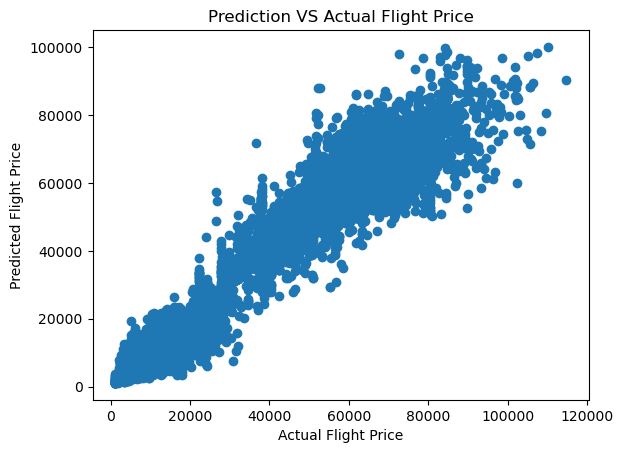

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Flight Price')

In [28]:
df.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [29]:
importances = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importances = sorted(
    importances.items(),
    key=lambda x: x[1],
    reverse=True
)

print(sorted_importances)

[('class', 0.8799711094384709), ('duration', 0.05763119427397485), ('days_left', 0.018583801555985924), ('airline_Air_India', 0.0058710235718433985), ('airline_Vistara', 0.004032235593803768), ('source_Delhi', 0.003780315407511316), ('dest_Delhi', 0.0034688101740009084), ('source_Mumbai', 0.002267989805960685), ('dest_Mumbai', 0.0019294969255236741), ('stops', 0.0018048556491554446), ('source_Kolkata', 0.0017421660435688582), ('dest_Kolkata', 0.0017354517997129684), ('dest_Hyderabad', 0.0015560372431069709), ('arrival_Evening', 0.0014511794559894917), ('dest_Bangalore', 0.0012530442367016698), ('source_Hyderabad', 0.0011919591818377949), ('arrival_Night', 0.0011209397630852953), ('departure_Evening', 0.0011138142207860135), ('source_Bangalore', 0.0010571052978977378), ('arrival_Afternoon', 0.0010008217996347252), ('departure_Morning', 0.0009193847807202367), ('source_Chennai', 0.0008988876615456513), ('dest_Chennai', 0.0008429284318256), ('departure_Afternoon', 0.000806169970788215), (

In [30]:
df.days_left.describe()

count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64

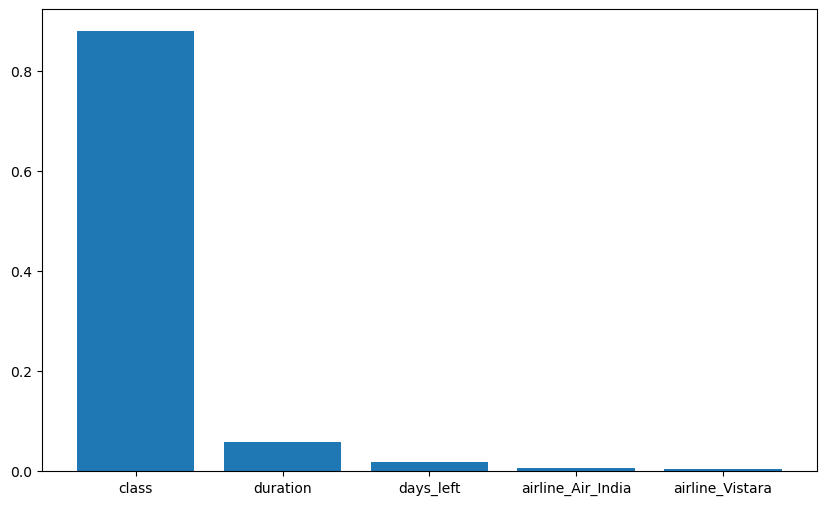

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    [x[0] for x in sorted_importances[:5]],
    [x[1] for x in sorted_importances[:5]]
)

plt.show()

In [32]:
print(df.shape)

(300153, 35)


In [33]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(
    n_estimators=10,
    random_state=10
)

reg.fit(X_train, y_train)
print("done")

done


In [41]:
X_train_small = X_train.sample(n=50000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [42]:
from sklearn.model_selection import GridSearchCV
reg = RandomForestRegressor(n_jobs=-1)
param_grid = {
    'n_estimators' : [100,200],
    'max_depth': [20,30],
    'min_samples_split': [2,5],
    'min_samples_leaf':[1,2],
    'max_features':[1.0,'sqrt']
}

grid_search = GridSearchCV(reg, param_grid, cv = 5,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


KeyboardInterrupt: 

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators' : randint(100,300),
    'max_depth': [None, 10,20,30,40,50],
    'min_samples_split': randint(2,11),
    'min_samples_leaf': randint(1,5),
    'max_features':[1.0,'sqrt']
}
reg = RandomForestRegressor(n_jobs=-1)

random_search = RandomizedSearchCV(estimator = reg, param_distributions = param_dist, n_iter = 2, cv =3,
                                  scoring='neg_mean_squared_error',verbose = 2,random_state = 10,n_jobs = -1)

random_search.fit(X_train, y_train)

best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits


In [43]:
best_regressor.score(X_test, y_test)

0.9863032076313446

In [46]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_regressor.predict(X_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred)))

R2:  0.9863032076313447
MAE:  1089.8796741297367
MSE:  7076410.38779722
RMSE:  2660.152324171911


Text(0.5, 1.0, 'Prediction VS Actual Flight Price')

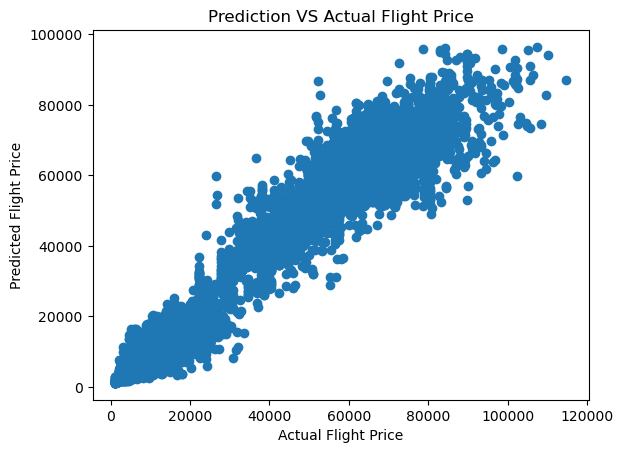

In [47]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Flight Price')